# Report: `ABaCo` fine-tuning and performance

## Simulated data

### Function definition for ZINB-like data

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import nbinom


def zinb_simulated(
    n_samples=200,
    n_features=1000,
    p_diff=0.5,
    b_diff=0.1,
    sims=1,
    bio_prop=[0.5, 0.5],
    batch_prop=[0.6, 0.4],
    seed=42,
):

    # ── 0. Reproducibility & basic parameters ─────────────────────────────────────
    np.random.seed(seed)

    n_diff = int(n_features * p_diff)
    n_bdiff = int(n_features * b_diff)

    bios = ["A", "B"]
    batches = ["Batch 1", "Batch 2"]

    sim_data_bt = []
    sim_data_gt = []


    # ── Global feature‐level params ────────────────────────────────────────────────
    r = np.random.uniform(1, 3, size=n_features)
    baseline_log = np.random.normal(2, 1, size=n_features)

    # zero-inflation
    high_zero_prop = int(
        n_features * 0.7
    )  # 70% of features being sparse with over-inflation of zeroes
    low_zero_prop = n_features - high_zero_prop

    high_zero = np.random.uniform(0.8, 0.9, high_zero_prop)
    low_zero = np.random.uniform(0.1, 0.8, low_zero_prop)

    z_target = np.concatenate([high_zero, low_zero])

    mu0 = np.exp(baseline_log)
    p_nb_zero = (r / (r + mu0)) ** r
    p_zero = np.clip((z_target - p_nb_zero) / (1 - p_nb_zero), 0, 1)

    # biological effects
    effect_sizes = np.zeros(n_features)
    idx_diff = np.random.choice(n_features, n_diff, replace=False)
    effect_sizes[idx_diff] = np.random.normal(2, 2, size=n_diff)
    effect_mult = 1 + 0.5 * (effect_sizes / effect_sizes.max())

    # batch effects
    batch_shift = np.zeros(n_features)
    idx_bdiff = np.random.choice(n_features, n_bdiff, replace=False)
    batch_shift[idx_bdiff] = np.random.normal(1, 2, size=n_bdiff)

    # heteroskedastic dispersion & zero‐inflation shifts by batch
    delta_disp = np.random.normal(0, 0.2, size=n_features)
    delta_zero = np.random.normal(0, 0.2, size=n_features)

    # bio×batch interaction
    idx_inter = np.random.choice(n_features, int(0.2 * n_features), replace=False)
    effect_int = np.zeros(n_features)
    effect_int[idx_inter] = np.random.normal(3, 1, size=idx_inter.size)

    # ── Simulation loop ────────────────────────────────────────────────────────────
    for sim in range(sims):
        # 1. Build metadata (no Plate or Age anymore)
        meta = pd.DataFrame(
            {
                "SampleID": [f"S{sim:02d}_{i+1}" for i in range(n_samples)],
                "Condition": np.random.choice(bios, size=n_samples, p=bio_prop),
                "Batch": np.random.choice(batches, size=n_samples, p=batch_prop),
            }
        )

        # placeholders for each scenario
        cnt_bt = np.zeros((n_samples, n_features), dtype=int)
        cnt_gt = np.zeros((n_samples, n_features), dtype=int)

        for i, row in meta.iterrows():
            cond = 1 if row.Condition == "B" else 0
            bat = 1 if row.Batch == "Batch 2" else 0

            # baseline log‐scale
            mu_log_base = baseline_log.copy()

            # --- Scenario 1: ground truth (no batch effect) ---
            mu_log3 = mu_log_base + cond * effect_sizes
            mu3 = np.exp(mu_log3)
            use_m = np.random.rand(n_features) < 0.3
            mu3[use_m] *= 1 + cond * effect_mult[use_m]
            p3 = r / (r + mu3)
            z3 = np.random.binomial(1, p_zero)
            samp3 = nbinom(r, p3).rvs(size=n_features)
            cnt_gt[i] = np.where(z3, 0, samp3)

            # --- Scenario 2: batch + bio + interaction ---
            mu_log4 = (
                mu_log_base
                + cond * effect_sizes
                + bat * batch_shift
                + cond * bat * effect_int
            )
            mu4 = np.exp(mu_log4)
            mu4[use_m] *= 1 + cond * effect_mult[use_m]
            r4 = r * (1 + bat * delta_disp)
            p04 = np.clip(p_zero * (1 + bat * delta_zero), 0, 1)
            p4 = r4 / (r4 + mu4)
            z4 = np.random.binomial(1, p04)
            samp4 = nbinom(r4, p4).rvs(size=n_features)

            cnt_bt[i] = np.where(z4, 0, samp4)

        cols = [f"OTU{j+1}" for j in range(n_features)]

        sim_data_bt.append(
            pd.concat([meta, pd.DataFrame(cnt_bt, columns=cols)], axis=1)
        )

        sim_data_gt.append(
            pd.concat([meta, pd.DataFrame(cnt_gt, columns=cols)], axis=1)
        )
    
    return sim_data_bt, sim_data_gt

### Data

In [2]:
bt, gt = zinb_simulated()

### PCoA

## Validation set for weights fine-tuning

### Sampling from dataset

In [3]:
import numpy as np

dataset = bt[0]
val_set = dataset.groupby(['Condition', 'Batch'], group_keys=False).apply(
    lambda g: g.sample(n=max(1, int(np.ceil(len(g) * 0.2))), random_state=42)
).reset_index(drop=True)

/tmp/ipykernel_3979270/2066609848.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  val_set = dataset.groupby(['Condition', 'Batch'], group_keys=False).apply(


### Training `ABaCo` model

In [4]:
from abaco.ABaCo import metaABaCo
import torch

batch_col = "Batch"
bio_col = "Condition"
id_col = "SampleID"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create ABaCo model
abaco_model = metaABaCo(
    data = val_set,
    n_bios = 2,
    bio_label = bio_col,
    n_batches=2,
    batch_label=batch_col,
    n_features=val_set.select_dtypes(include="number").shape[1],
    prior="VMM",
    device=device,
    epochs=[5000, 2000, 1000]
)

abaco_model.fit(seed=42,
                w_cluster_penalty=10.0,
                w_bio_penalty=10.0,
                w_elbo_kl=10.0,
                phase_1_vae_lr=2e-4,
                phase_2_vae_lr=1e-6,
                phase_3_vae_lr=1e-6,
                disc_lr=1e-7,
                adv_lr=1e-7)

Training: VAE for learning meaningful embeddings: 100%|██████████| 5000/5000 [01:32<00:00, 53.87it/s, bio_penalty=0.0014, clustering_loss=0.0013, elbo=8132.8320, epoch=4999/5001, vae_loss=8132.8350]     
Training: Embeddings batch effect correction using adversrial training: 100%|██████████| 2000/2000 [00:39<00:00, 50.03it/s, adv_loss=-0.7710, bio_penalty=0.0004, clustering_loss=0.0000, disc_loss=0.7710, elbo=1401.0730, epoch=1999/2001, vae_loss=1401.0734]
Training: VAE decoder with masked batch labels: 100%|██████████| 1000/1000 [00:09<00:00, 106.70it/s, cycle_loss=0.0000, epoch=1000/1000, vae_loss=1346.8971]


### Function

In [5]:
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import DistanceMatrix, permanova
from skbio.stats.ordination import pcoa
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import pandas as pd
import numpy as np

# Auxiliary
def permanova_ait(df, sample_label, group_label):
    samples = df[sample_label].values
    groups = df[group_label].values
    clr_data = df.select_dtypes(include = "number").values

    aitch = pdist(clr_data, metric = "euclidean")
    dist_mat = squareform(aitch)
    dm = DistanceMatrix(dist_mat, ids=samples)

    res_ait = permanova(distance_matrix=dm, grouping=groups)

    res_ait["R2"] = (
        res_ait["test statistic"]
        * (len(np.unique(groups)) - 1)
        / (
            res_ait["test statistic"] * (len(np.unique(groups)) - 1)
            + (len(samples) - len(np.unique(groups)))
        )
    )
    return res_ait

def pcoa_aitchison(df, sample_label, batch_label, bio_label):
    df_otu = df.select_dtypes(include="number")
    dist = pdist(df_otu, "euclidean")
    dist = squareform(dist)

    pcoa_res = pcoa(dist)
    explained = (pcoa_res.proportion_explained * 100).round(1)
    explained_dict = {"PC1": explained[0], "PC2": explained[1]}
    df_pcoa = pd.DataFrame(pcoa_res.samples[["PC1","PC2"]], columns=["PC1","PC2"])
    df_pcoa.index = (
        df.index
    )
    df_pcoa[[sample_label, batch_label, bio_label]] = df[[sample_label, batch_label, bio_label]]
    return df_pcoa, explained_dict

def plot_pcoa_2(
    df_pcoa,
    group_col,
    df,
    sample_label,
    ax,
    explained,
    palette=None,
    xlim=None,
    ylim=None,
    marginal_size="20%",     # size of marginals relative to main
    marginal_pad=0.1,         # padding between main and marginals
    kde_bw_adjust=1.0,        # bandwidth scaling for KDE
    alpha_kde=0.5,            # fill transparency for KDE areas
    title=None,               # optional title above the top density plot
    show_legend=True          # whether to draw the legend
):
    # compute PERMANOVA R2
    perma_r2 = permanova_ait(df, sample_label, group_col)["R2"]

    # set up axes divider for marginals
    divider = make_axes_locatable(ax)
    ax_top   = divider.append_axes("top",    size=marginal_size, pad=marginal_pad, sharex=ax)
    ax_right = divider.append_axes("right",  size=marginal_size, pad=marginal_pad, sharey=ax)

    # hide the marginal axes completely (no ticks, no spines)
    ax_top.axis('off')
    ax_right.axis('off')

    groups = df_pcoa[group_col].unique()
    colors = palette or plt.cm.tab10.colors

    handles = []
    labels  = []

    for i, grp in enumerate(groups):
        sub = df_pcoa[df_pcoa[group_col] == grp]
        x = sub['PC1'].values
        y = sub['PC2'].values
        c = colors[i % len(colors)]

        # main scatter
        pts = ax.scatter(x, y, label=str(grp), alpha=0.7, color=c)
        handles.append(pts)
        labels.append(str(grp))

        # marginal KDEs (axes are off so only the filled area shows)
        sns.kdeplot(
            x=x, ax=ax_top, bw_adjust=kde_bw_adjust,
            fill=True, alpha=alpha_kde, color=c, linewidth=1.5
        )
        sns.kdeplot(
            y=y, ax=ax_right, bw_adjust=kde_bw_adjust,
            fill=True, alpha=alpha_kde, color=c, linewidth=1.5
        )

        # 95% confidence ellipse
        cov = np.cov(x, y)
        vals, vecs = np.linalg.eigh(cov)
        width, height = 2 * np.sqrt(vals * 5.991)
        angle = np.degrees(np.arctan2(*vecs[:,0][::-1]))
        ell = Ellipse(
            xy=(x.mean(), y.mean()),
            width=width, height=height,
            angle=angle, edgecolor=c, facecolor='none', lw=2
        )
        ax.add_patch(ell)

    # add title above the top density plot
    if title:
        ax_top.set_title(title, pad=10, fontsize=16)

    # optionally draw legend on top density axis
    if show_legend:
        ax_top.legend(
            handles, labels,
            title=group_col,
            bbox_to_anchor=(1.02, 1), loc='upper left',
            frameon=False,
            fontsize=14,
            title_fontsize=16,
        )

    # main axis formatting
    ax.set_xlabel(f"PC1 ({explained['PC1']:.1f}%)", fontsize=12)
    ax.set_ylabel(f"PC2 ({explained['PC2']:.1f}%)", fontsize=12)
    ax.text(
        0.99, 0.99,
        f"PERMANOVA R² ({group_col}): {perma_r2:.3f}",
        transform=ax.transAxes, ha="right", va="top", fontsize="small"
    )
    ax.set_aspect('equal')

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

### PCoA

/tmp/ipykernel_3979270/2689478418.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  explained_dict = {"PC1": explained[0], "PC2": explained[1]}


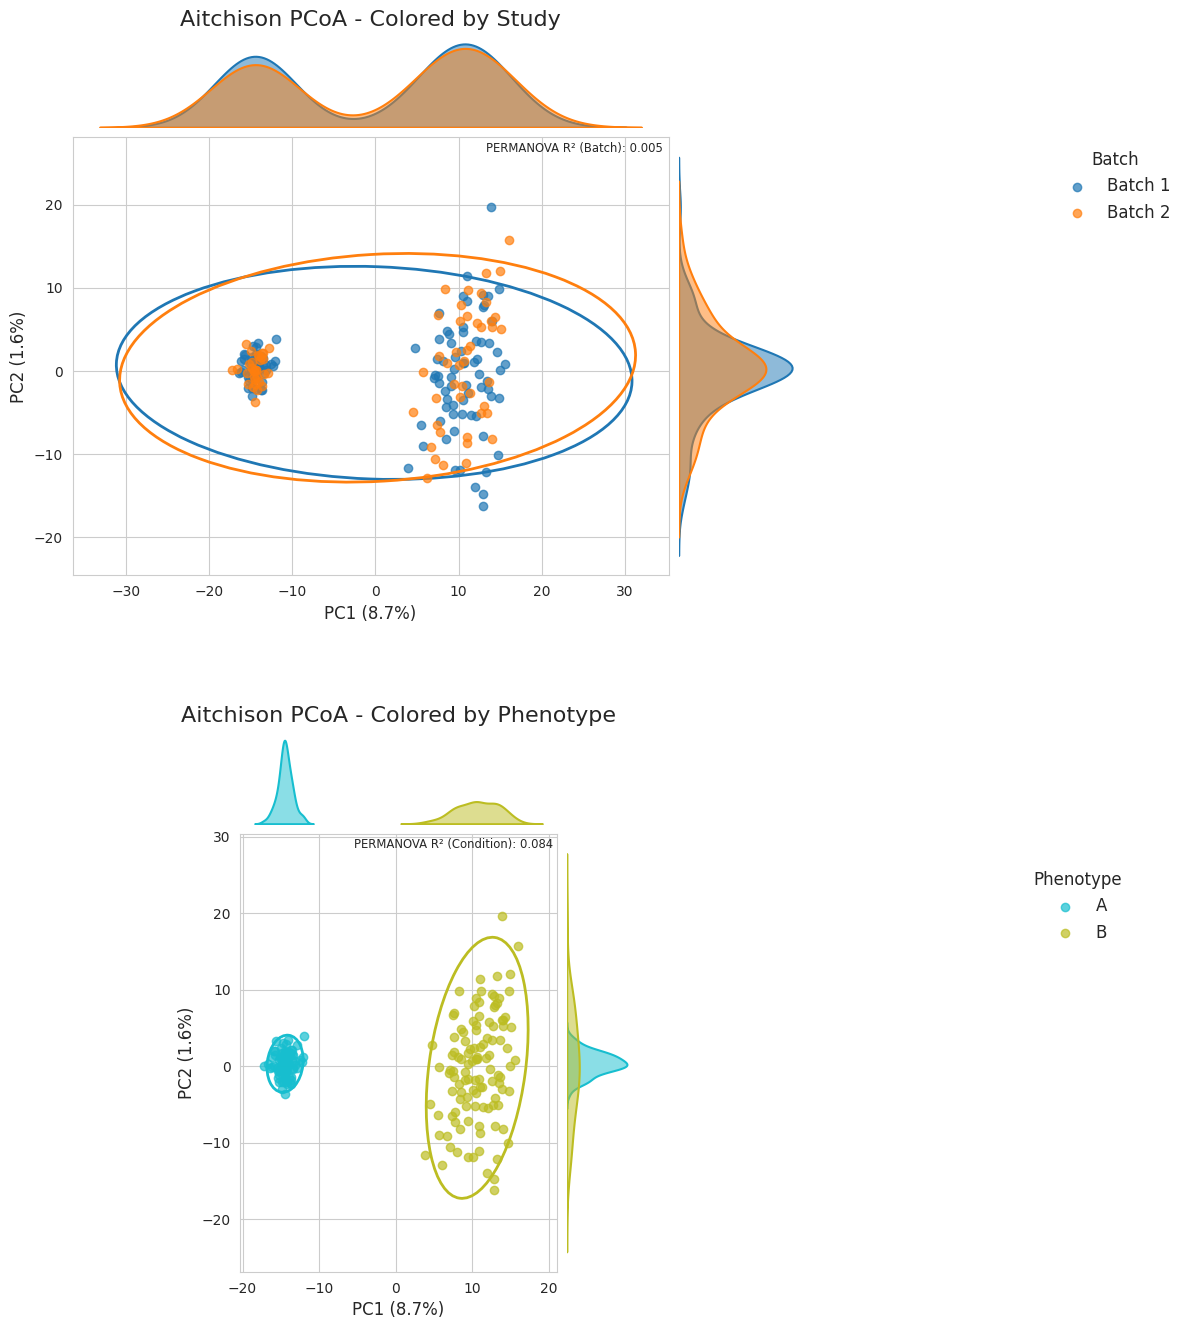

In [6]:
# Define figure
from abaco.dataloader import DataTransform

sns.set_style("whitegrid")
fig = plt.figure(figsize=(24, 16))
fig.suptitle("", fontsize=16, y=0.97)

gs = GridSpec(2, 1, figure=fig, wspace=0.4, hspace=0.3)

top_palette = sns.color_palette("tab10", n_colors=9)
bottom_palette = sns.color_palette("tab10", n_colors=10)[::-1][:9]

ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[1,0])

data_clr = DataTransform(gt[0], factors=[id_col, batch_col, bio_col], count=True)

data_pcoa, data_exp = pcoa_aitchison(
    data_clr,
    sample_label=id_col,
    batch_label=batch_col,
    bio_label=bio_col
)

plot_pcoa_2(
    data_pcoa,
    group_col=batch_col,
    df=data_clr,
    sample_label=id_col,
    ax=ax1,
    explained=data_exp,
    palette=top_palette,
    title="Aitchison PCoA - Colored by Study",
    show_legend=False
)

handles, labels = ax1.get_legend_handles_labels()

fig.legend(
    handles, labels,
    title="Batch",
    loc = "upper right",
    frameon = False,
    bbox_to_anchor = (0.8, 0.82),
    fontsize=12,
    title_fontsize=12
)

plot_pcoa_2(
    data_pcoa,
    group_col=bio_col,
    df=data_clr,
    sample_label=id_col,
    ax=ax2,
    explained=data_exp,
    palette=bottom_palette,
    title="Aitchison PCoA - Colored by Phenotype",
    show_legend=False
)

handles, labels = ax2.get_legend_handles_labels()

fig.legend(
    handles, labels,
    title="Phenotype",
    loc = "upper right",
    frameon = False,
    bbox_to_anchor = (0.78, 0.37),
    fontsize=12,
    title_fontsize=12
)

fig.subplots_adjust(right=0.85)

plt.show()

/tmp/ipykernel_3979270/2689478418.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  explained_dict = {"PC1": explained[0], "PC2": explained[1]}


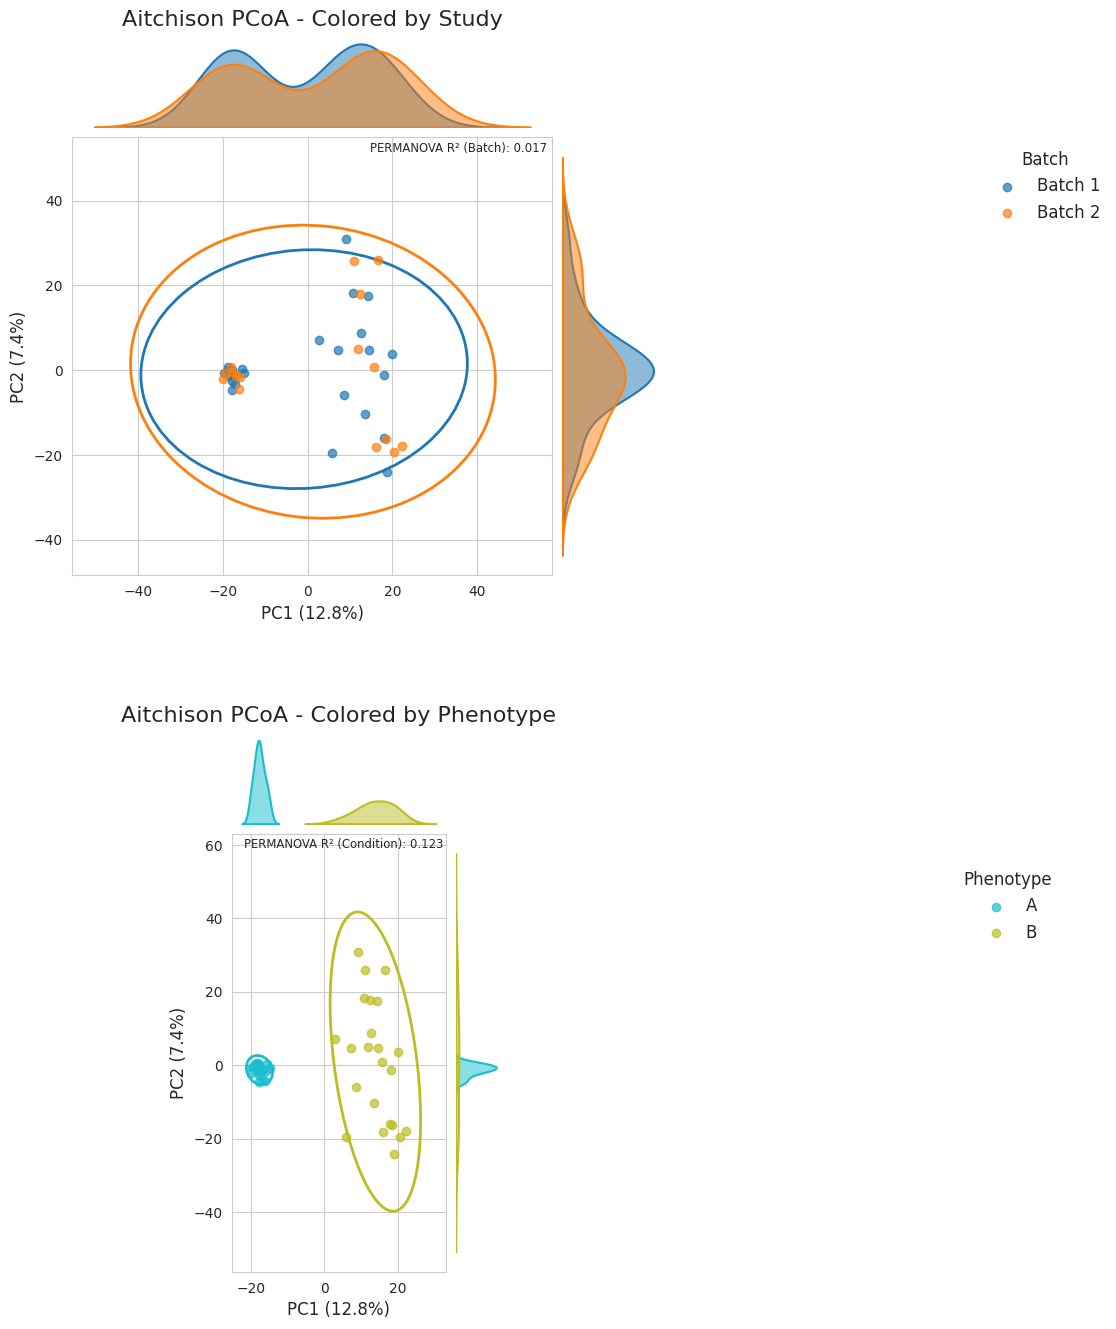

In [7]:
# Define figure
corrected_dataset = abaco_model.correct(seed=42)

sns.set_style("whitegrid")
fig = plt.figure(figsize=(24, 16))
fig.suptitle("", fontsize=16, y=0.97)

gs = GridSpec(2, 1, figure=fig, wspace=0.4, hspace=0.3)

top_palette = sns.color_palette("tab10", n_colors=9)
bottom_palette = sns.color_palette("tab10", n_colors=10)[::-1][:9]

ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[1,0])

corrected_data_clr = DataTransform(corrected_dataset, factors=[id_col, batch_col, bio_col], count=True)

data_pcoa, data_exp = pcoa_aitchison(
    corrected_data_clr,
    sample_label=id_col,
    batch_label=batch_col,
    bio_label=bio_col
)

plot_pcoa_2(
    data_pcoa,
    group_col=batch_col,
    df=corrected_data_clr,
    sample_label=id_col,
    ax=ax1,
    explained=data_exp,
    palette=top_palette,
    title="Aitchison PCoA - Colored by Study",
    show_legend=False
)

handles, labels = ax1.get_legend_handles_labels()

fig.legend(
    handles, labels,
    title="Batch",
    loc = "upper right",
    frameon = False,
    bbox_to_anchor = (0.8, 0.82),
    fontsize=12,
    title_fontsize=12
)

plot_pcoa_2(
    data_pcoa,
    group_col=bio_col,
    df=corrected_data_clr,
    sample_label=id_col,
    ax=ax2,
    explained=data_exp,
    palette=bottom_palette,
    title="Aitchison PCoA - Colored by Phenotype",
    show_legend=False
)

handles, labels = ax2.get_legend_handles_labels()

fig.legend(
    handles, labels,
    title="Phenotype",
    loc = "upper right",
    frameon = False,
    bbox_to_anchor = (0.78, 0.37),
    fontsize=12,
    title_fontsize=12
)

fig.subplots_adjust(right=0.85)

plt.show()

## Mock example: Performance during training

In [8]:
import time
import psutil
import GPUtil

# Samples x Taxa
sample_n = [100, 200]
taxa_n = [100, 200]

perf_records = []

for sn in sample_n:
    for tn in taxa_n:
        # Generate simulated data
        bt, gt = zinb_simulated(
            n_samples=sn,
            n_features=tn,
        )

        # Define dataset
        dataset = bt[0]

        # Run abaco on dataset
        batch_col = "Batch"
        bio_col = "Condition"
        id_col = "SampleID"

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # for performance metrics
        proc = psutil.Process()
        # --- pre‐run snapshots ---
        t0_wall = time.time()
        t0_cpu = sum(proc.cpu_times()[:2])  # user + sys CPU s
        mem0 = proc.memory_info().rss  # resident set size
        torch.cuda.reset_peak_memory_stats()  # clear PyTorch peak

        abaco_model = metaABaCo(
            data = dataset,
            n_bios = 2,
            bio_label = bio_col,
            n_batches=2,
            batch_label=batch_col,
            n_features=dataset.select_dtypes(include="number").shape[1],
            prior="VMM",
            device=device
        )

        recon_data = abaco_model.fit(seed=42)

        # --- post‐run snapshots ---
        t1_wall = time.time()
        t1_cpu = sum(proc.cpu_times()[:2])
        mem1 = proc.memory_info().rss
        peak_gpu = torch.cuda.max_memory_allocated()

        # --- GPU‐side current status ---
        gpus = GPUtil.getGPUs()

        # collect metrics
        ram_change_gib = (mem1 - mem0) / 1024**3
        peak_gpu_gib = peak_gpu / 1024**3
        gpu_info = "; ".join(
            [
            f"GPU {g.id}: util={g.load*100:.1f}%, mem={g.memoryUsed/1024**3:.1f}/{g.memoryTotal/1024**3:.1f}GiB"
            for g in gpus
            ]
        )

        perf_records.append(
            {
            "n_samples": sn,
            "n_features": tn,
            "wall_s": t1_wall - t0_wall,
            "cpu_s": t1_cpu - t0_cpu,
            "ram_change_gib": ram_change_gib,
            "peak_gpu_gib": peak_gpu_gib,
            "gpu_info": gpu_info,
            }
        )

perf_records_df = pd.DataFrame(perf_records)
perf_records_df.head()

Training: VAE for learning meaningful embeddings:   0%|          | 0/1000 [00:00<?, ?it/s]

Training: VAE for learning meaningful embeddings: 100%|██████████| 1000/1000 [00:17<00:00, 58.01it/s, bio_penalty=0.0822, clustering_loss=0.0742, elbo=143.6458, epoch=999/1001, vae_loss=143.8022]   
Training: Embeddings batch effect correction using adversrial training: 100%|██████████| 2000/2000 [00:38<00:00, 52.17it/s, adv_loss=-0.6730, bio_penalty=0.6929, clustering_loss=0.0000, disc_loss=0.6730, elbo=154.8363, epoch=1999/2001, vae_loss=155.5292]    
Training: VAE for learning meaningful embeddings: 100%|██████████| 1000/1000 [00:18<00:00, 54.08it/s, bio_penalty=0.0144, clustering_loss=0.0140, elbo=297.1100, epoch=999/1001, vae_loss=297.1384]  
Training: Embeddings batch effect correction using adversrial training: 100%|██████████| 2000/2000 [00:39<00:00, 50.95it/s, adv_loss=-0.6691, bio_penalty=0.6541, clustering_loss=0.0000, disc_loss=0.6691, elbo=334.2989, epoch=1999/2001, vae_loss=334.9529] 
Training: VAE for learning meaningful embeddings: 100%|██████████| 1000/1000 [00:20<00:0

,n_samples,n_features,wall_s,cpu_s,ram_change_gib,peak_gpu_gib,gpu_info
0,100,100,73.331969,74.52,0.000240,0.035872,"GPU 0: util=18.0%, mem=0.0/0.0GiB; GPU 1: util..."
1,100,200,76.617790,77.79,0.003674,0.041905,"GPU 0: util=15.0%, mem=0.0/0.0GiB; GPU 1: util..."
2,200,100,88.268054,89.48,-0.003429,0.034855,"GPU 0: util=14.0%, mem=0.0/0.0GiB; GPU 1: util..."
3,200,200,94.824520,95.99,0.002110,0.042996,"GPU 0: util=12.0%, mem=0.0/0.0GiB; GPU 1: util..."


## Interpolation report on performance

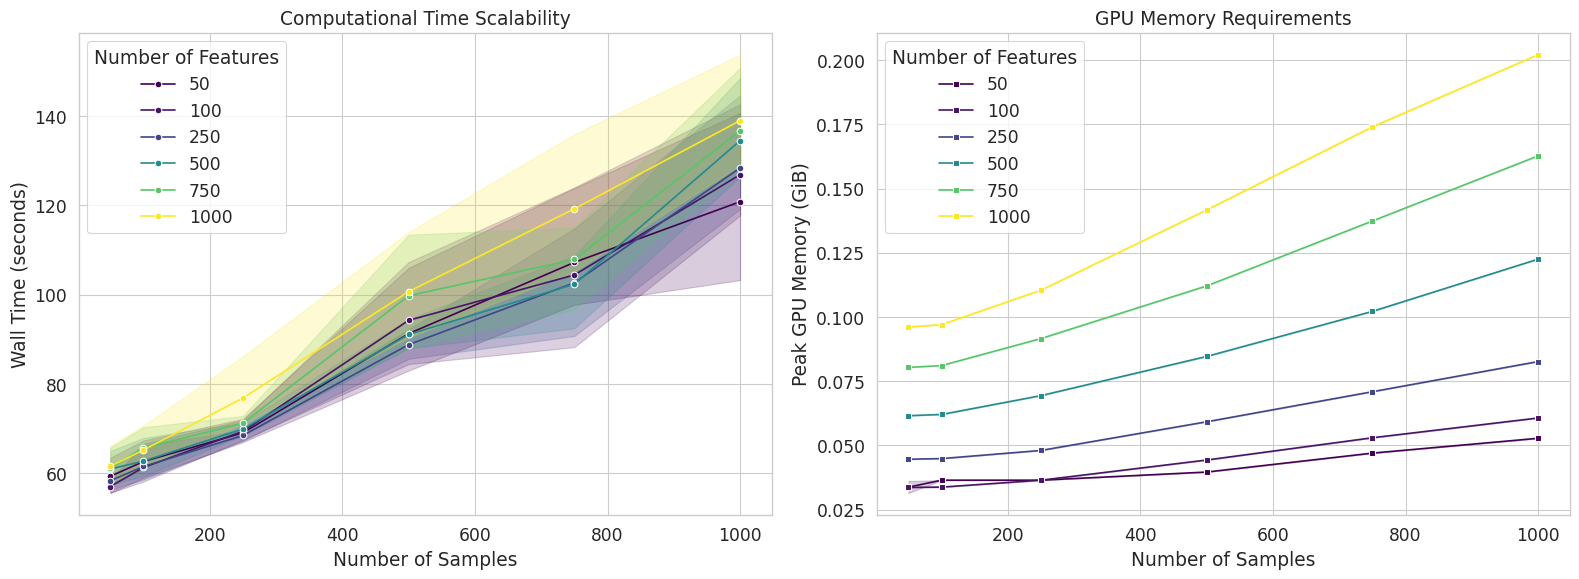

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# choose metric
metric = 'wall_s'

# load data
path = "data/abaco_performance_interpolation_iter.csv"
df = pd.read_csv(path)

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.4)

# Subplot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Runtime Analysis ---
sns.lineplot(
    data=df, 
    x="n_samples", 
    y="wall_s", 
    hue="n_features", 
    palette="viridis",      
    marker="o",             
    ax=axes[0]
)

axes[0].set_title("Computational Time Scalability")
axes[0].set_xlabel("Number of Samples")
axes[0].set_ylabel("Wall Time (seconds)")
axes[0].legend(title="Number of Features")

# --- Plot 2: Memory Usage Analysis ---
sns.lineplot(
    data=df, 
    x="n_samples", 
    y="peak_gpu_gib", 
    hue="n_features", 
    palette="viridis",        
    marker="s",             
    ax=axes[1]
)

axes[1].set_title("GPU Memory Requirements")
axes[1].set_xlabel("Number of Samples")
axes[1].set_ylabel("Peak GPU Memory (GiB)")
axes[1].legend(title="Number of Features")

# Adjust layout and save
plt.tight_layout()
plt.show()